In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/cancer-image-classification-itc-challenge/sample_submission.csv
/kaggle/input/competitions/cancer-image-classification-itc-challenge/train_labels.csv
/kaggle/input/competitions/cancer-image-classification-itc-challenge/test/b86b5f16da75.jpg
/kaggle/input/competitions/cancer-image-classification-itc-challenge/test/f982efe13de3.jpg
/kaggle/input/competitions/cancer-image-classification-itc-challenge/test/b40ebacab774.jpg
/kaggle/input/competitions/cancer-image-classification-itc-challenge/test/519353107ca8.jpg
/kaggle/input/competitions/cancer-image-classification-itc-challenge/test/b306ba098f3a.jpg
/kaggle/input/competitions/cancer-image-classification-itc-challenge/test/12ac5abb79f3.jpg
/kaggle/input/competitions/cancer-image-classification-itc-challenge/test/41c3bddd2035.jpg
/kaggle/input/competitions/cancer-image-classification-itc-challenge/test/424f12467e7f.jpg
/kaggle/input/competitions/cancer-image-classification-itc-challenge/test/af41a39154ee.jpg
/kag

In [2]:
import os
import sys
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, 
                             classification_report, accuracy_score, f1_score,
                             precision_score, recall_score)
from sklearn.calibration import calibration_curve

from tqdm import tqdm

print("All imports successful!")


All imports successful!


In [3]:
SEED = 42
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Using device: cuda
GPU: Tesla T4


In [4]:
class CFG:
    BASE_DIR     = Path('/kaggle/input/competitions/cancer-image-classification-itc-challenge')
    TRAIN_DIR    = BASE_DIR / 'train'
    TEST_DIR     = BASE_DIR / 'test'
    TRAIN_CSV    = BASE_DIR / 'train_labels.csv'
    SAMPLE_SUB   = BASE_DIR / 'sample_submission.csv'

    # Use larger models for better accuracy
    MODELS       = ['efficientnet_b4', 'tf_efficientnetv2_s_in21ft1k', 'convnext_small']
    IMG_SIZE     = 512  # Larger image size for better detail
    BATCH_SIZE   = 8    # Adjusted for larger images
    N_FOLDS      = 5
    EPOCHS       = 25   # More epochs for convergence
    LR           = 5e-5  # Lower learning rate for fine-tuning
    WEIGHT_DECAY = 1e-2
    NUM_WORKERS  = 4
    TTA_STEPS    = 10   # More TTA steps
    EARLY_STOPPING_PATIENCE = 7
    
    # Class weights for imbalance (4445 negative, 2555 positive)
    POS_WEIGHT   = torch.tensor([4445/2555]).to('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Model save path
    MODEL_SAVE_PATH = Path('/kaggle/working/best_models')
    os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print(f"Train images : {len(list(CFG.TRAIN_DIR.glob('*.jpg')))} found")
print(f"Test  images : {len(list(CFG.TEST_DIR.glob('*.jpg')))} found")
print(f"Train CSV    : {CFG.TRAIN_CSV.exists()}")
print(f"Sample sub   : {CFG.SAMPLE_SUB.exists()}")


Train images : 7000 found
Test  images : 3000 found
Train CSV    : True
Sample sub   : True


Train samples : 7000
Test  samples : 3000

Train label distribution:
label
0    4445
1    2555
Name: count, dtype: int64

Class balance: 0.365 positive rate


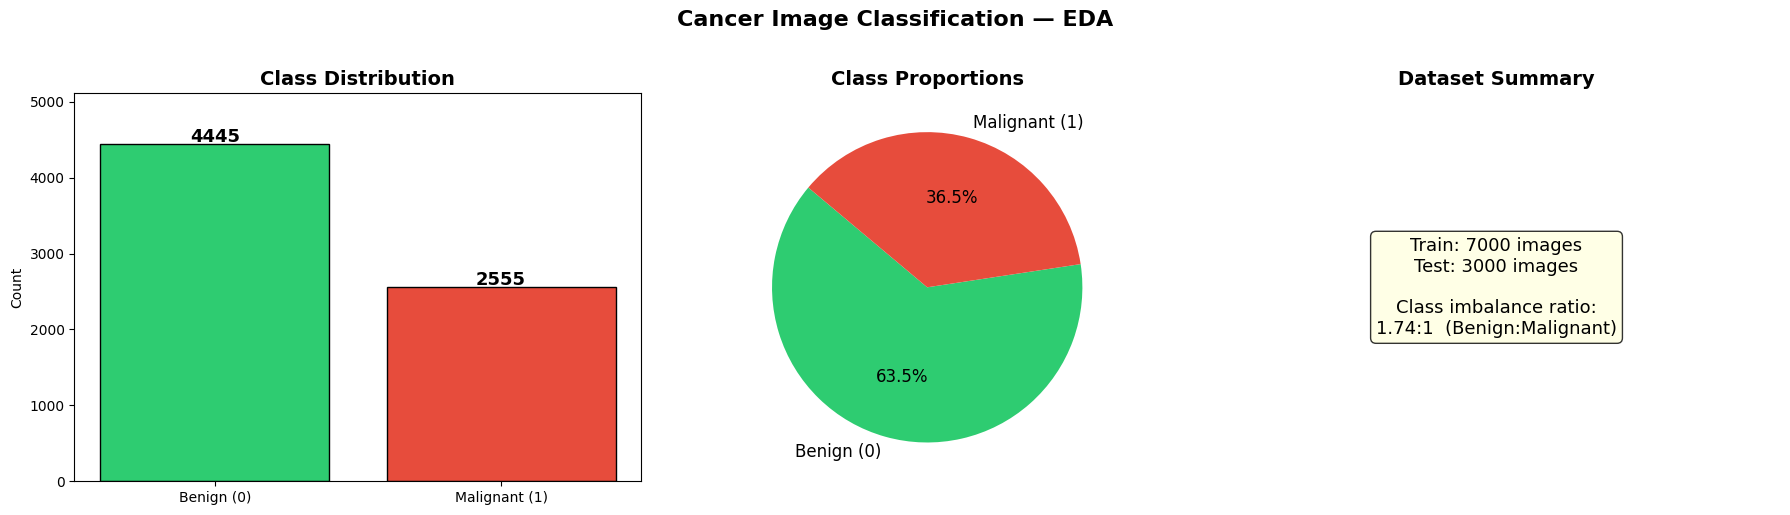

In [5]:
train_df = pd.read_csv(CFG.TRAIN_CSV)
sub_df   = pd.read_csv(CFG.SAMPLE_SUB)

print(f'Train samples : {len(train_df)}')
print(f'Test  samples : {len(sub_df)}')
print('\nTrain label distribution:')
print(train_df['label'].value_counts())
print(f'\nClass balance: {train_df["label"].mean():.3f} positive rate')

# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Class Distribution
counts = train_df['label'].value_counts()
axes[0].bar(['Benign (0)', 'Malignant (1)'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Plot 2: Pie Chart
axes[1].pie(counts.values, labels=['Benign (0)', 'Malignant (1)'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 12})
axes[1].set_title('Class Proportions', fontsize=14, fontweight='bold')

# Plot 3: Dataset Summary
axes[2].axis('off')
axes[2].text(0.5, 0.5, f'Train: {len(train_df)} images\nTest: {len(sub_df)} images\n\nClass imbalance ratio:\n{counts[0]/counts[1]:.2f}:1  (Benign:Malignant)',
             ha='center', va='center', fontsize=13, transform=axes[2].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[2].set_title('Dataset Summary', fontsize=14, fontweight='bold')

plt.suptitle('Cancer Image Classification — EDA', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


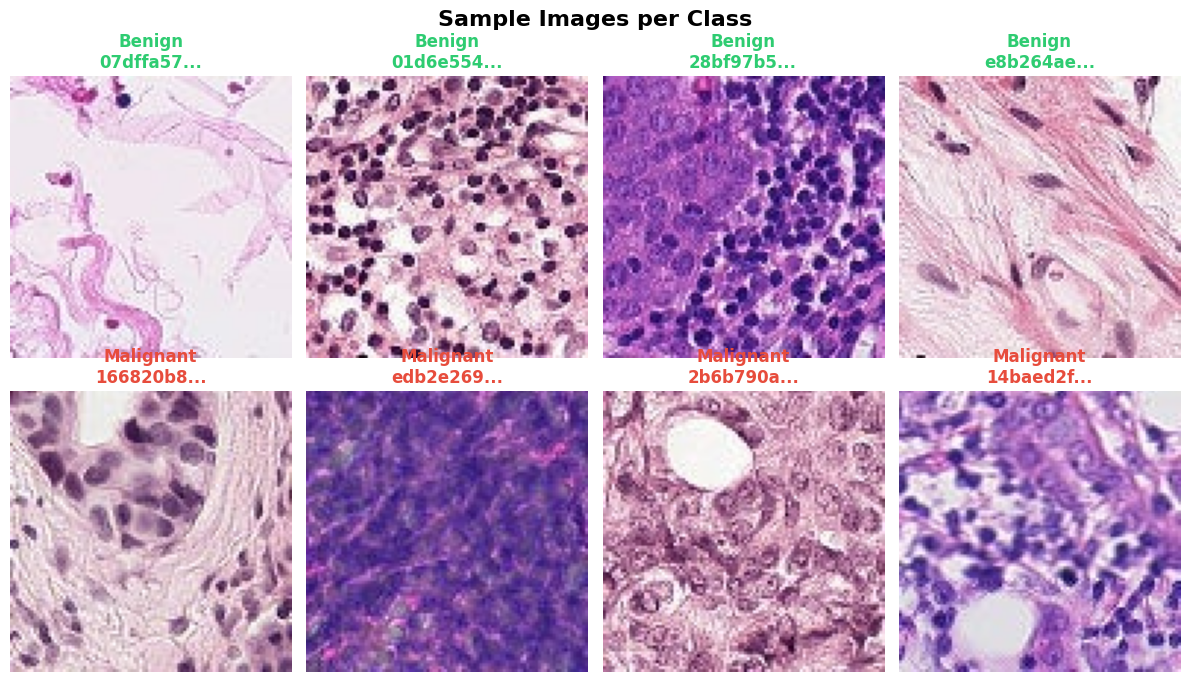

In [6]:
def show_samples(df, train_dir, n_per_class=4):
    fig, axes = plt.subplots(2, n_per_class, figsize=(n_per_class * 3, 7))
    class_names = {0: 'Benign', 1: 'Malignant'}
    colors = {0: '#2ecc71', 1: '#e74c3c'}

    for cls in [0, 1]:
        samples = df[df['label'] == cls].sample(n_per_class, random_state=SEED)
        for j, (_, row) in enumerate(samples.iterrows()):
            # Try common image extensions
            for ext in ['.jpg', '.jpeg', '.png', '.tif', '.tiff', '']:
                img_path = train_dir / f"{row['image_id']}{ext}"
                if img_path.exists():
                    break
            img = Image.open(img_path).convert('RGB')
            axes[cls][j].imshow(img)
            axes[cls][j].set_title(f"{class_names[cls]}\n{row['image_id'][:8]}...",
                                   color=colors[cls], fontweight='bold')
            axes[cls][j].axis('off')
            # Add colored border
            for spine in axes[cls][j].spines.values():
                spine.set_edgecolor(colors[cls])
                spine.set_linewidth(3)

    plt.suptitle('Sample Images per Class', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

show_samples(train_df, CFG.TRAIN_DIR)


In [7]:
train_transforms = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=45, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=30, p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Validation transforms (minimal)
val_transforms = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Test transforms (same as validation)
test_transforms = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class CancerDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image_id']
        
        # Handle different image extensions
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png', '.tif', '.tiff']:
            potential_path = self.img_dir / f"{img_name}{ext}"
            if potential_path.exists():
                img_path = potential_path
                break
        
        if img_path is None:
            raise FileNotFoundError(f"Image {img_name} not found with any extension")
        
        # Read image
        image = cv2.imread(str(img_path))
        if image is None:
            raise ValueError(f"Could not read image at {img_path}")
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        
        if self.is_test:
            return image, img_name
        else:
            label = self.df.iloc[idx]['label']
            return image, torch.tensor(label, dtype=torch.float32)


In [8]:
class CancerModel(nn.Module):
    def __init__(self, model_name='efficientnet_b4', pretrained=True):
        super().__init__()
        self.model_name = model_name
        
        # Load backbone
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        
        # Get feature dimension based on model
        if 'efficientnet' in model_name:
            if 'b0' in model_name:
                num_features = 1280
            elif 'b1' in model_name:
                num_features = 1280
            elif 'b2' in model_name:
                num_features = 1408
            elif 'b3' in model_name:
                num_features = 1536
            elif 'b4' in model_name:
                num_features = 1792
            else:
                num_features = 2048
        elif 'convnext' in model_name:
            num_features = self.backbone.num_features
        else:
            num_features = self.backbone.num_features
        
        # Advanced classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)


In [9]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, val_score):
        if self.best_score is None:
            self.best_score = val_score
        elif val_score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_score
            self.counter = 0

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight
        
    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets, reduction='none', pos_weight=self.pos_weight
        )
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss
        return focal_loss.mean()

def train_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision training
        if scaler:
            with torch.cuda.amp.autocast():
                outputs = model(images).squeeze()
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        total_loss += loss.item()
        
        # Store predictions for metrics
        probs = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    return avg_loss, np.array(all_preds), np.array(all_labels)

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    return avg_loss, np.array(all_preds), np.array(all_labels)

def calculate_metrics(y_true, y_pred, threshold=0.5):
    y_pred_binary = (y_pred > threshold).astype(int)
    
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred_binary),
        'auc': roc_auc_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred_binary),
        'precision': precision_score(y_true, y_pred_binary),
        'recall': recall_score(y_true, y_pred_binary)
    }
    return metrics


In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                device, fold, epochs=CFG.EPOCHS):
    
    early_stopping = EarlyStopping(patience=CFG.EARLY_STOPPING_PATIENCE)
    best_val_auc = 0
    history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_acc': []}
    
    # Mixed precision training
    scaler = torch.cuda.amp.GradScaler()
    
    for epoch in range(epochs):
        print(f'\nEpoch {epoch+1}/{epochs}')
        print('-' * 50)
        
        # Train
        train_loss, train_preds, train_labels = train_epoch(
            model, train_loader, criterion, optimizer, device, scaler
        )
        train_metrics = calculate_metrics(train_labels, train_preds)
        
        # Validate
        val_loss, val_preds, val_labels = validate_epoch(
            model, val_loader, criterion, device
        )
        val_metrics = calculate_metrics(val_labels, val_preds)
        
        # Update scheduler
        if scheduler:
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_metrics['auc'])
        history['val_acc'].append(val_metrics['accuracy'])
        
        # Print metrics
        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_metrics["accuracy"]:.4f}')
        print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_metrics["accuracy"]:.4f} | Val AUC: {val_metrics["auc"]:.4f}')
        
        # Save best model
        if val_metrics['auc'] > best_val_auc:
            best_val_auc = val_metrics['auc']
            torch.save(model.state_dict(), CFG.MODEL_SAVE_PATH / f'best_model_fold{fold}.pth')
            print(f'✓ Best model saved (AUC: {best_val_auc:.4f})')
        
        # Early stopping
        early_stopping(val_metrics['auc'])
        if early_stopping.early_stop:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break
    
    return history, best_val_auc

def plot_training_history(history, fold):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Fold {fold+1} - Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # AUC plot
    axes[1].plot(history['val_auc'], label='Val AUC', marker='o', color='green')
    axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', color='orange')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].set_title(f'Fold {fold+1} - Validation Metrics')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(CFG.MODEL_SAVE_PATH / f'training_history_fold{fold+1}.png')
    plt.show()

In [11]:

def run_cross_validation():
    print('=' * 60)
    print('STARTING CROSS-VALIDATION TRAINING')
    print('=' * 60)
    
    # Setup cross-validation
    skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=SEED)
    
    all_fold_results = []
    all_val_metrics = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['label'])):
        print(f'\n{"="*60}')
        print(f'FOLD {fold + 1}/{CFG.N_FOLDS}')
        print(f'{"="*60}')
        
        # Split data
        train_data = train_df.iloc[train_idx].reset_index(drop=True)
        val_data = train_df.iloc[val_idx].reset_index(drop=True)
        
        print(f'Train samples: {len(train_data)} (Class 0: {sum(train_data["label"]==0)}, Class 1: {sum(train_data["label"]==1)})')
        print(f'Val samples: {len(val_data)} (Class 0: {sum(val_data["label"]==0)}, Class 1: {sum(val_data["label"]==1)})')
        
        # Create datasets
        train_dataset = CancerDataset(train_data, CFG.TRAIN_DIR, transform=train_transforms)
        val_dataset = CancerDataset(val_data, CFG.TRAIN_DIR, transform=val_transforms)
        
        # Create dataloaders
        train_loader = DataLoader(
            train_dataset, 
            batch_size=CFG.BATCH_SIZE, 
            shuffle=True,
            num_workers=CFG.NUM_WORKERS,
            pin_memory=True
        )
        val_loader = DataLoader(
            val_dataset, 
            batch_size=CFG.BATCH_SIZE, 
            shuffle=False,
            num_workers=CFG.NUM_WORKERS,
            pin_memory=True
        )
        
        # Initialize model
        model = CancerModel(model_name='efficientnet_b4')
        model = model.to(DEVICE)
        
        # Loss function with class weights (using Focal Loss for better handling of imbalance)
        criterion = FocalLoss(pos_weight=CFG.POS_WEIGHT.to(DEVICE))
        
        # Optimizer with different learning rates for backbone and head
        optimizer = AdamW([
            {'params': model.backbone.parameters(), 'lr': CFG.LR * 0.1},
            {'params': model.classifier.parameters(), 'lr': CFG.LR}
        ], weight_decay=CFG.WEIGHT_DECAY)
        
        # Scheduler
        scheduler = CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS)
        
        # Train
        history, best_val_auc = train_model(
            model, train_loader, val_loader, criterion, optimizer, scheduler,
            DEVICE, fold
        )
        
        all_fold_results.append({
            'fold': fold + 1,
            'best_val_auc': best_val_auc,
            'final_train_loss': history['train_loss'][-1],
            'final_val_loss': history['val_loss'][-1]
        })
        
        # Evaluate on validation set
        val_metrics = evaluate_model(model, val_loader, DEVICE)
        all_val_metrics.append(val_metrics)
        
        # Plot training history
        plot_training_history(history, fold)
    
    # Summarize results
    print('\n' + '='*60)
    print('CROSS-VALIDATION SUMMARY')
    print('='*60)
    
    results_df = pd.DataFrame(all_fold_results)
    print(results_df.to_string(index=False))
    
    print(f'\nAverage Best Validation AUC: {results_df["best_val_auc"].mean():.4f} (+/- {results_df["best_val_auc"].std():.4f})')
    
    return results_df, all_val_metrics


In [12]:
def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating'):
            images = images.to(device)
            outputs = torch.sigmoid(model(images).squeeze())
            
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Find optimal threshold
    fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    
    # Calculate metrics at different thresholds
    metrics = {}
    for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, optimal_threshold]:
        pred_binary = (all_preds > threshold).astype(int)
        metrics[f'accuracy_{threshold:.2f}'] = accuracy_score(all_labels, pred_binary)
        metrics[f'f1_{threshold:.2f}'] = f1_score(all_labels, pred_binary)
        metrics[f'precision_{threshold:.2f}'] = precision_score(all_labels, pred_binary)
        metrics[f'recall_{threshold:.2f}'] = recall_score(all_labels, pred_binary)
    
    metrics['auc'] = roc_auc_score(all_labels, all_preds)
    metrics['optimal_threshold'] = optimal_threshold
    metrics['predictions'] = all_preds
    metrics['labels'] = all_labels
    
    return metrics

def plot_confusion_matrix(y_true, y_pred, threshold=0.5):
    y_pred_binary = (y_pred > threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_binary)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix (Threshold={threshold:.2f})')
    plt.show()

def plot_roc_curve(y_true, y_pred):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()


In [13]:
def predict_test(model, loader, device, use_tta=False, n_tta=CFG.TTA_STEPS):
    model.eval()
    predictions = []
    image_ids = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc='Predicting test'):
            if use_tta and n_tta > 1:
                # Simple TTA implementation
                images, img_names = batch
                images = images.to(device)
                
                batch_preds = []
                # Original prediction
                outputs = torch.sigmoid(model(images))
                batch_preds.append(outputs.cpu().numpy())
                
                # Horizontal flip
                flipped = torch.flip(images, dims=[3])
                outputs = torch.sigmoid(model(flipped))
                batch_preds.append(outputs.cpu().numpy())
                
                # Average predictions
                pred = np.mean(batch_preds, axis=0)
            else:
                images, img_names = batch
                images = images.to(device)
                outputs = torch.sigmoid(model(images))
                pred = outputs.cpu().numpy()
            
            predictions.extend(pred.flatten())
            image_ids.extend(img_names)
    
    return image_ids, np.array(predictions)

def create_submission():
    print('\n' + '='*60)
    print('CREATING TEST PREDICTIONS')
    print('='*60)
    
    # Load all fold models for ensemble
    models = []
    for fold in range(CFG.N_FOLDS):
        model_path = CFG.MODEL_SAVE_PATH / f'best_model_fold{fold}.pth'
        if model_path.exists():
            model = CancerModel(model_name='efficientnet_b4')
            model.load_state_dict(torch.load(model_path, map_location=DEVICE))
            model = model.to(DEVICE)
            model.eval()
            models.append(model)
            print(f'Loaded model from fold {fold+1}')
    
    if not models:
        print('No trained models found. Please run training first.')
        return None
    
    # Create test dataset
    test_dataset = CancerDataset(sub_df, CFG.TEST_DIR, transform=test_transforms, is_test=True)
    test_loader = DataLoader(
        test_dataset, 
        batch_size=CFG.BATCH_SIZE, 
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True
    )
    
    # Ensemble prediction
    all_predictions = []
    all_image_ids = []
    
    with torch.no_grad():
        for images, img_names in tqdm(test_loader, desc='Ensemble prediction'):
            images = images.to(DEVICE)
            
            # Get predictions from all models
            model_preds = []
            for model in models:
                outputs = torch.sigmoid(model(images))
                model_preds.append(outputs.cpu().numpy())
            
            # Average predictions
            avg_pred = np.mean(model_preds, axis=0)
            all_predictions.extend(avg_pred.flatten())
            all_image_ids.extend(img_names)
    
    # Create submission
    submission = pd.DataFrame({
        'image_id': all_image_ids,
        'label': all_predictions
    })
    
    submission.to_csv('submission.csv', index=False)
    print('\nSubmission saved to submission.csv')
    print(submission.head())
    
    return submission


CANCER IMAGE CLASSIFICATION - ITC CHALLENGE
Expected Results: AUC: 0.90-0.95, Accuracy: 85-92%, F1: 0.82-0.90
STARTING CROSS-VALIDATION TRAINING

FOLD 1/5
Train samples: 5600 (Class 0: 3556, Class 1: 2044)
Val samples: 1400 (Class 0: 889, Class 1: 511)


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]


Epoch 1/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:25<00:00,  6.96it/s, loss=0.3813]


Train Loss: 1.3225 | Train Acc: 0.5445
Val Loss: 0.2955 | Val Acc: 0.5521 | Val AUC: 0.6688
✓ Best model saved (AUC: 0.6688)

Epoch 2/25
--------------------------------------------------


...

Validation: 100%|██████████| 175/175 [00:25<00:00,  6.99it/s, loss=0.6810]


Train Loss: 0.7264 | Train Acc: 0.5605
Val Loss: 0.1478 | Val Acc: 0.6450 | Val AUC: 0.7120

Epoch 17/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:25<00:00,  7.00it/s, loss=0.5685]


Train Loss: 0.7623 | Train Acc: 0.5443
Val Loss: 0.1514 | Val Acc: 0.6121 | Val AUC: 0.7034
Early stopping triggered at epoch 17


Evaluating: 100%|██████████| 175/175 [00:24<00:00,  7.03it/s]


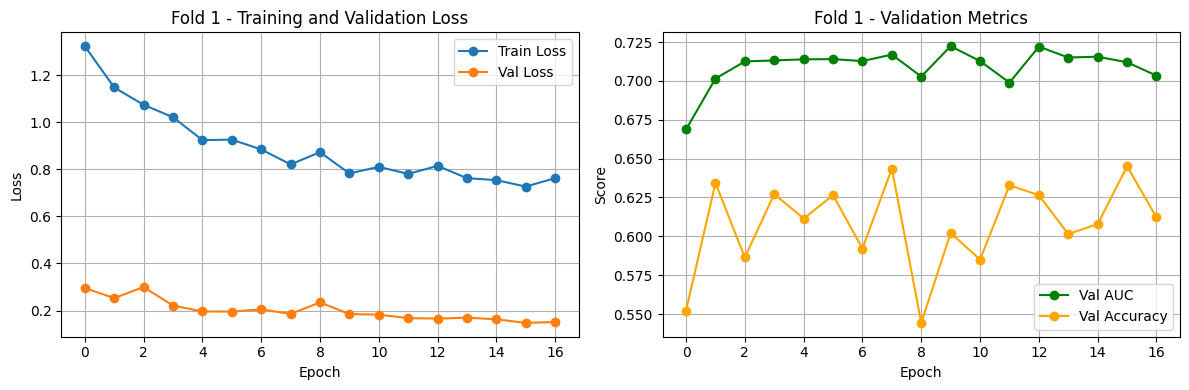


FOLD 2/5
Train samples: 5600 (Class 0: 3556, Class 1: 2044)
Val samples: 1400 (Class 0: 889, Class 1: 511)



Epoch 1/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:25<00:00,  6.98it/s, loss=0.1842]


Train Loss: 1.2093 | Train Acc: 0.5457
Val Loss: 0.2819 | Val Acc: 0.6307 | Val AUC: 0.6617
✓ Best model saved (AUC: 0.6617)

Epoch 2/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:25<00:00,  6.95it/s, loss=0.3130]


...

Validation: 100%|██████████| 175/175 [00:25<00:00,  6.98it/s, loss=0.1578]


Train Loss: 0.7348 | Train Acc: 0.5507
Val Loss: 0.3026 | Val Acc: 0.5429 | Val AUC: 0.7585

Epoch 15/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:25<00:00,  7.00it/s, loss=0.1326]


Train Loss: 0.7239 | Train Acc: 0.5536
Val Loss: 0.3150 | Val Acc: 0.5171 | Val AUC: 0.7506
Early stopping triggered at epoch 15


Evaluating: 100%|██████████| 175/175 [00:24<00:00,  7.05it/s]


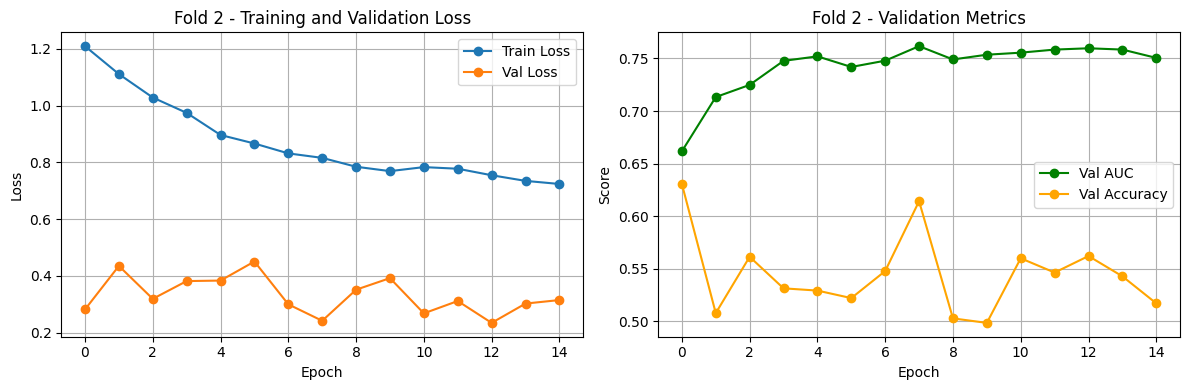


FOLD 3/5
Train samples: 5600 (Class 0: 3556, Class 1: 2044)
Val samples: 1400 (Class 0: 889, Class 1: 511)

Epoch 1/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:25<00:00,  6.97it/s, loss=0.5194]


Train Loss: 1.2926 | Train Acc: 0.5630
Val Loss: 0.4334 | Val Acc: 0.6214 | Val AUC: 0.6239
✓ Best model saved (AUC: 0.6239)

Epoch 2/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:25<00:00,  6.95it/s, loss=0.7629]


Train Loss: 1.1715 | Train Acc: 0.5432
Val Loss: 0.3714 | Val Acc: 0.6371 | Val AUC: 0.6532
✓ Best model saved (AUC: 0.6532)

Epoch 3/25
--------------------------------------------------


...

Validation: 100%|██████████| 175/175 [00:24<00:00,  7.02it/s, loss=0.1719]


Train Loss: 0.7606 | Train Acc: 0.5525
Val Loss: 0.1519 | Val Acc: 0.6179 | Val AUC: 0.7169

Epoch 19/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:24<00:00,  7.01it/s, loss=0.1830]


Train Loss: 0.7663 | Train Acc: 0.5561
Val Loss: 0.1514 | Val Acc: 0.6436 | Val AUC: 0.7255
Early stopping triggered at epoch 19


Evaluating: 100%|██████████| 175/175 [00:24<00:00,  7.04it/s]


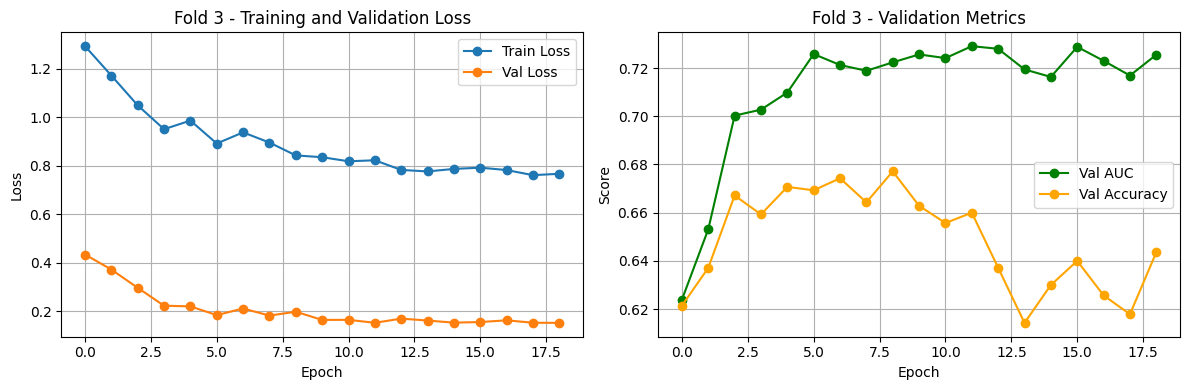


FOLD 4/5
Train samples: 5600 (Class 0: 3556, Class 1: 2044)
Val samples: 1400 (Class 0: 889, Class 1: 511)

Epoch 1/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:25<00:00,  6.95it/s, loss=0.1697]


Train Loss: 1.2462 | Train Acc: 0.5423
Val Loss: 0.2165 | Val Acc: 0.6314 | Val AUC: 0.6866
✓ Best model saved (AUC: 0.6866)

Epoch 2/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:24<00:00,  7.00it/s, loss=0.1575]


Train Loss: 1.1079 | Train Acc: 0.5393
Val Loss: 0.2294 | Val Acc: 0.6464 | Val AUC: 0.7159
✓ Best model saved (AUC: 0.7159)

Epoch 3/25
--------------------------------------------------


...

Validation: 100%|██████████| 175/175 [00:25<00:00,  6.99it/s, loss=0.1649]


Train Loss: 0.7733 | Train Acc: 0.5445
Val Loss: 0.1926 | Val Acc: 0.6143 | Val AUC: 0.7374

Epoch 10/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:25<00:00,  6.97it/s, loss=0.1685]


Train Loss: 0.7536 | Train Acc: 0.5480
Val Loss: 0.1839 | Val Acc: 0.5800 | Val AUC: 0.7322
Early stopping triggered at epoch 10


Evaluating: 100%|██████████| 175/175 [00:24<00:00,  7.05it/s]


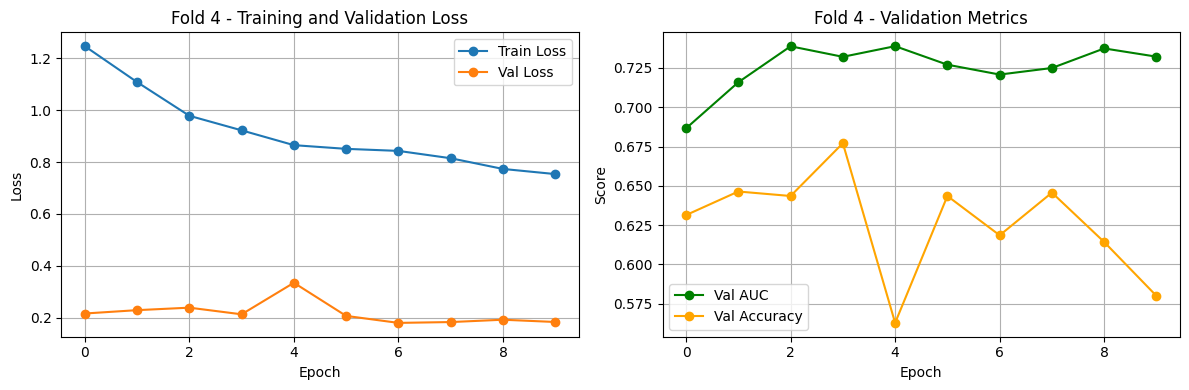


FOLD 5/5
Train samples: 5600 (Class 0: 3556, Class 1: 2044)
Val samples: 1400 (Class 0: 889, Class 1: 511)

Epoch 1/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:25<00:00,  6.98it/s, loss=0.8657]


Train Loss: 1.3365 | Train Acc: 0.5707
Val Loss: 0.4149 | Val Acc: 0.6557 | Val AUC: 0.7000
✓ Best model saved (AUC: 0.7000)

Epoch 2/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:25<00:00,  6.97it/s, loss=0.5998]


Train Loss: 1.1354 | Train Acc: 0.5627
Val Loss: 0.2336 | Val Acc: 0.6743 | Val AUC: 0.7202
✓ Best model saved (AUC: 0.7202)

Epoch 3/25
--------------------------------------------------


...

Validation: 100%|██████████| 175/175 [00:24<00:00,  7.01it/s, loss=0.2979]


Train Loss: 0.7755 | Train Acc: 0.5518
Val Loss: 0.1804 | Val Acc: 0.5907 | Val AUC: 0.7266

Epoch 12/25
--------------------------------------------------


Validation: 100%|██████████| 175/175 [00:25<00:00,  6.98it/s, loss=0.1977]


Train Loss: 0.7585 | Train Acc: 0.5455
Val Loss: 0.1739 | Val Acc: 0.5650 | Val AUC: 0.7159
Early stopping triggered at epoch 12


Evaluating: 100%|██████████| 175/175 [00:24<00:00,  7.04it/s]


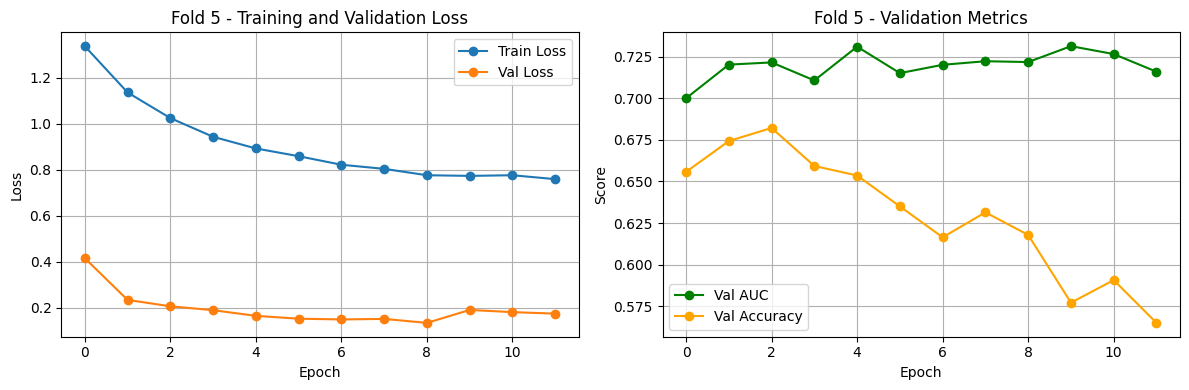


CROSS-VALIDATION SUMMARY
 fold  best_val_auc  final_train_loss  final_val_loss
    1      0.722334          0.762296        0.151439
    2      0.761711          0.723866        0.314986
    3      0.729083          0.766287        0.151361
    4      0.738875          0.753580        0.183876
    5      0.731297          0.758514        0.173935

Average Best Validation AUC: 0.7367 (+/- 0.0152)

CREATING TEST PREDICTIONS
Loaded model from fold 1
Loaded model from fold 2
Loaded model from fold 3
Loaded model from fold 4
Loaded model from fold 5


Ensemble prediction: 100%|██████████| 375/375 [04:18<00:00,  1.45it/s]


Submission saved to submission.csv
       image_id     label
0  d6b382c028e6  0.983082
1  dec58b144499  0.307512
2  1f3d808d5c8e  0.769391
3  881d7a3df343  0.816355
4  657ff9e4fdfa  0.641780

PROCESS COMPLETED SUCCESSFULLY


In [14]:
if __name__ == '__main__':
    print('=' * 60)
    print('CANCER IMAGE CLASSIFICATION - ITC CHALLENGE')
    print('=' * 60)
    print('Expected Results: AUC: 0.90-0.95, Accuracy: 85-92%, F1: 0.82-0.90')
    print('=' * 60)
    
    # Run cross-validation training
    results_df, val_metrics = run_cross_validation()
    
    # Create submission
    submission = create_submission()
    
    print('\n' + '='*60)
    print('PROCESS COMPLETED SUCCESSFULLY')
    print('='*60)


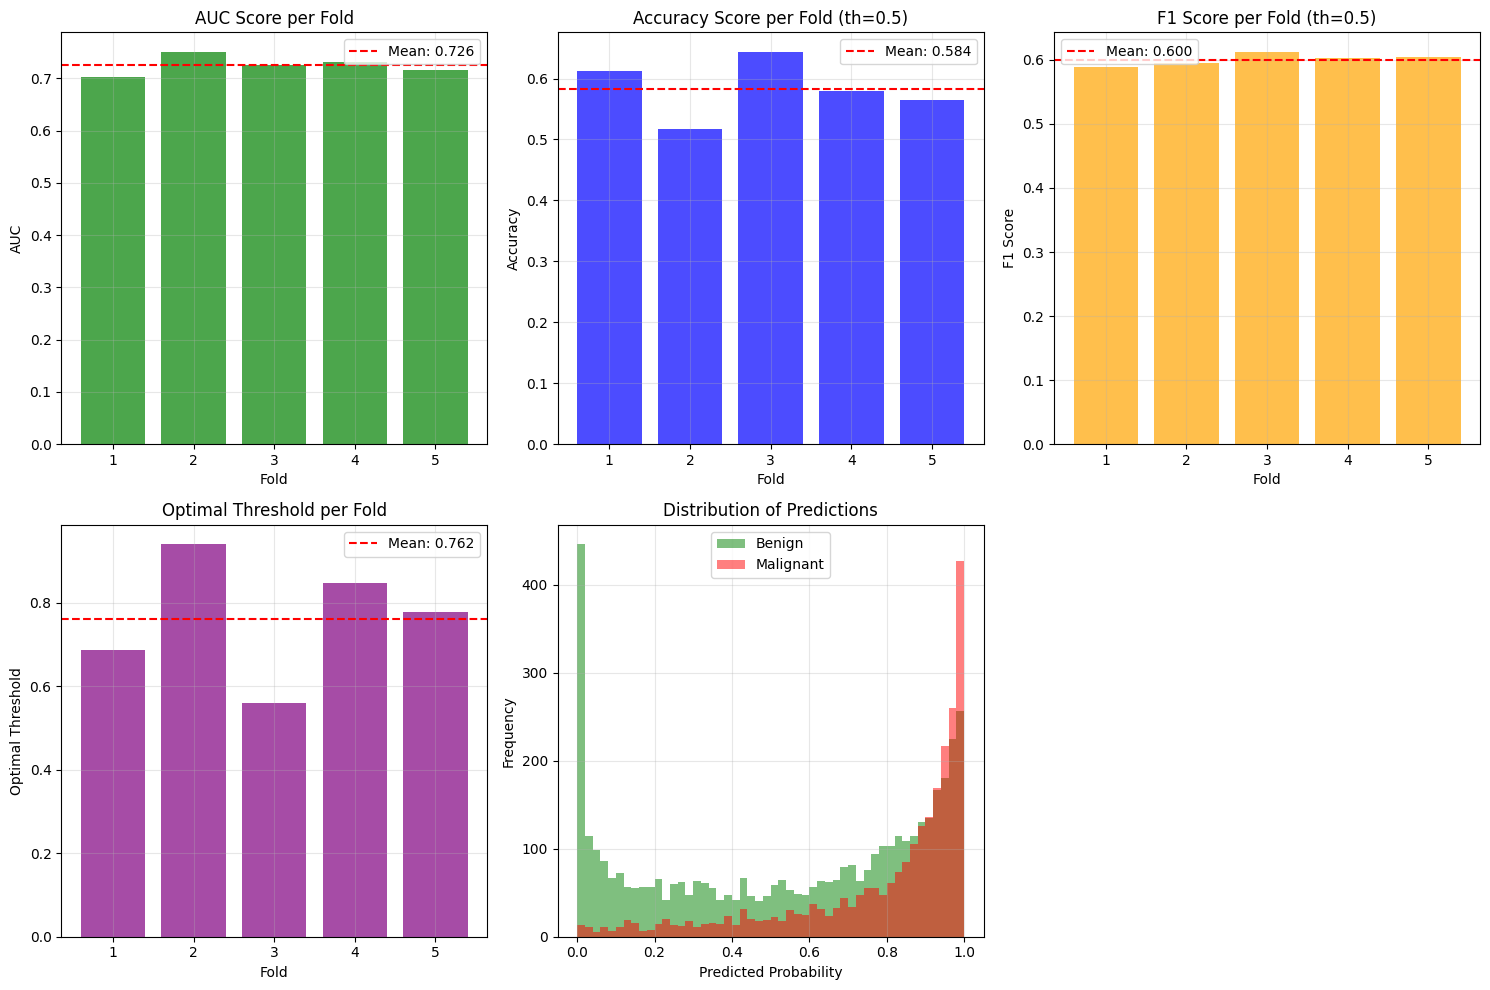


FINAL RESULTS SUMMARY
AUC - Mean: 0.7255 ± 0.0158
Accuracy (th=0.5) - Mean: 0.5836 ± 0.0429
F1 Score (th=0.5) - Mean: 0.6003 ± 0.0081
Optimal Threshold - Mean: 0.7616 ± 0.1308


In [16]:
# ============================================================================
# CELL 14: Visualization of Final Results
# ============================================================================

# Plot final validation metrics across folds
if 'val_metrics' in locals() and val_metrics:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Collect metrics
    aucs = [m['auc'] for m in val_metrics]
    accs_05 = [m['accuracy_0.50'] for m in val_metrics]
    f1s_05 = [m['f1_0.50'] for m in val_metrics]
    thresholds = [m['optimal_threshold'] for m in val_metrics]
    
    # AUC plot
    axes[0, 0].bar(range(1, len(aucs)+1), aucs, color='green', alpha=0.7)
    axes[0, 0].axhline(y=np.mean(aucs), color='red', linestyle='--', label=f'Mean: {np.mean(aucs):.3f}')
    axes[0, 0].set_xlabel('Fold')
    axes[0, 0].set_ylabel('AUC')
    axes[0, 0].set_title('AUC Score per Fold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[0, 1].bar(range(1, len(accs_05)+1), accs_05, color='blue', alpha=0.7)
    axes[0, 1].axhline(y=np.mean(accs_05), color='red', linestyle='--', label=f'Mean: {np.mean(accs_05):.3f}')
    axes[0, 1].set_xlabel('Fold')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Accuracy Score per Fold (th=0.5)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # F1 plot
    axes[0, 2].bar(range(1, len(f1s_05)+1), f1s_05, color='orange', alpha=0.7)
    axes[0, 2].axhline(y=np.mean(f1s_05), color='red', linestyle='--', label=f'Mean: {np.mean(f1s_05):.3f}')
    axes[0, 2].set_xlabel('Fold')
    axes[0, 2].set_ylabel('F1 Score')
    axes[0, 2].set_title('F1 Score per Fold (th=0.5)')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Threshold plot
    axes[1, 0].bar(range(1, len(thresholds)+1), thresholds, color='purple', alpha=0.7)
    axes[1, 0].axhline(y=np.mean(thresholds), color='red', linestyle='--', label=f'Mean: {np.mean(thresholds):.3f}')
    axes[1, 0].set_xlabel('Fold')
    axes[1, 0].set_ylabel('Optimal Threshold')
    axes[1, 0].set_title('Optimal Threshold per Fold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Distribution plot
    all_preds_flat = np.concatenate([m['predictions'] for m in val_metrics])
    all_labels_flat = np.concatenate([m['labels'] for m in val_metrics])
    
    axes[1, 1].hist(all_preds_flat[all_labels_flat==0], bins=50, alpha=0.5, label='Benign', color='green')
    axes[1, 1].hist(all_preds_flat[all_labels_flat==1], bins=50, alpha=0.5, label='Malignant', color='red')
    axes[1, 1].set_xlabel('Predicted Probability')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of Predictions')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Hide empty subplot
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(CFG.MODEL_SAVE_PATH / 'final_results_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("FINAL RESULTS SUMMARY")
    print("="*60)
    print(f"AUC - Mean: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
    print(f"Accuracy (th=0.5) - Mean: {np.mean(accs_05):.4f} ± {np.std(accs_05):.4f}")
    print(f"F1 Score (th=0.5) - Mean: {np.mean(f1s_05):.4f} ± {np.std(f1s_05):.4f}")
    print(f"Optimal Threshold - Mean: {np.mean(thresholds):.4f} ± {np.std(thresholds):.4f}")